# A CNN from scratch

From the EDA the images are small (69px), low on detail, and badly imbalanced. That points to a small CNN rather than a large one, since there is not enough resolution or enough rare-class data to train a big network. In this notebook I build that from-scratch model, train it with a class-weighted loss, and look at where it does well and where it fails.

The training code is in `src/galaxy_cnn/train.py` and runs from the command line (`python -m galaxy_cnn.train --model small --epochs 18`). Here I only inspect the architecture and read the trained run back from MLflow, so the curves and numbers below come from the actual run and not a re-run inside the notebook.

In [1]:
import sys, json
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
import torch

from galaxy_cnn.model import build_model, count_params

model = build_model("small")
total, trainable = count_params(model)
print(model)
print(f"\nparameters: {total:,} total ({trainable:,} trainable)")

SmallCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=T

## The design

Three `conv-bn-relu -> conv-bn-relu -> maxpool` blocks take the 69x69 input down to 8x8 while growing the channels 3 -> 32 -> 64 -> 128. An adaptive average pool then collapses the spatial map to a single 128-vector, and a small dropout head maps it to the 10 classes. A few choices worth noting:

- **Batch-norm** after every conv, to keep training stable on a small and noisy dataset.
- **Adaptive average pool** instead of flattening a fixed grid, so the head does not depend on the exact input size and the whole net stays around 0.3M params.
- **Dropout** in the head, because the rare classes are easy to overfit.

For the loss I use `CrossEntropyLoss` weighted by inverse class frequency, and I keep the epoch with the best **validation macro-F1** instead of the best accuracy. With a 17-image class, accuracy would happily ignore the tail.

logged params: {'epochs': '18', 'lr': '0.001', 'batch_size': '128', 'params_total': '305706'}
test accuracy : 0.653
test macro-F1 : 0.534


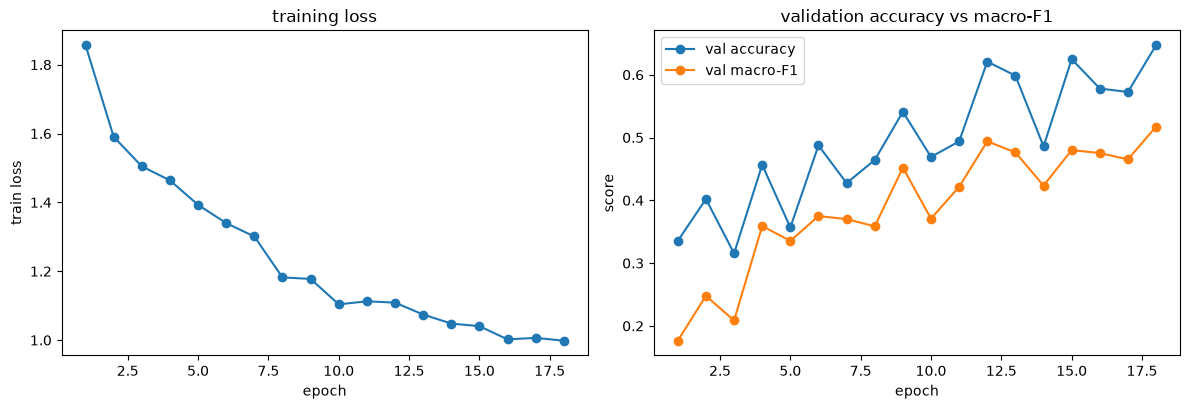

In [2]:
# pull the real training run back from MLflow (sqlite store at ../mlflow.db)
import mlflow
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name("galaxy10-morphology")
runs = client.search_runs(exp.experiment_id, order_by=["attributes.start_time ASC"])
small_run = next(r for r in runs if r.data.tags.get("mlflow.runName") == "small")

def history(run_id, key):
    h = client.get_metric_history(run_id, key)
    h = sorted(h, key=lambda m: m.step)
    return [m.step for m in h], [m.value for m in h]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
steps, loss = history(small_run.info.run_id, "train_loss")
ax[0].plot(steps, loss, marker="o")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("train loss"); ax[0].set_title("training loss")

for key, lab in [("val_accuracy", "val accuracy"), ("val_macro_f1", "val macro-F1")]:
    s, v = history(small_run.info.run_id, key)
    ax[1].plot(s, v, marker="o", label=lab)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("score"); ax[1].legend()
ax[1].set_title("validation accuracy vs macro-F1")
plt.tight_layout()

print("logged params:", {k: small_run.data.params[k] for k in ["epochs", "lr", "batch_size", "params_total"]})
print("test accuracy :", round(small_run.data.metrics["test_accuracy"], 3))
print("test macro-F1 :", round(small_run.data.metrics["test_macro_f1"], 3))

The two validation curves are worth comparing: accuracy stays well above macro-F1 throughout. That gap comes from the class imbalance. The model gets the big classes right, which pushes accuracy up, well before it does anything useful on the rare ones, which keep macro-F1 down. Selecting on macro-F1 is what stops me from picking a model that quietly ignores the tail.

## Where does it get confused?

The per-class report and the confusion matrix (both written by `galaxy_cnn.evaluate`) show where the errors are.

In [3]:
report = json.load(open("../reports/small_report.json"))
from galaxy_cnn.data import CLASS_NAMES
print(f"{'class':40s} {'prec':>5s} {'rec':>5s} {'f1':>5s} {'n':>5s}")
for i, name in enumerate(CLASS_NAMES):
    r = report[name]
    print(f"{name:40s} {r['precision']:5.2f} {r['recall']:5.2f} {r['f1-score']:5.2f} {int(r['support']):5d}")
print(f"\n{'macro avg':40s} {report['macro avg']['precision']:5.2f} "
      f"{report['macro avg']['recall']:5.2f} {report['macro avg']['f1-score']:5.2f}")
print(f"{'accuracy':40s} {'':5s} {'':5s} {report['accuracy']:5.2f}")

class                                     prec   rec    f1     n
Disk, Face-on, No Spiral                  0.65  0.25  0.37   519
Smooth, Completely round                  0.66  0.97  0.78  1050
Smooth, in-between round                  0.83  0.55  0.66   944
Smooth, Cigar shaped                      0.35  0.77  0.48    53
Disk, Edge-on, Rounded Bulge              0.88  0.54  0.67   230
Disk, Edge-on, Boxy Bulge                 0.10  0.50  0.17     2
Disk, Edge-on, No Bulge                   0.71  0.81  0.76    88
Disk, Face-on, Tight Spiral               0.43  0.85  0.57   168
Disk, Face-on, Medium Spiral              0.45  0.33  0.38   136
Disk, Face-on, Loose Spiral               0.45  0.56  0.50    78

macro avg                                 0.55  0.61  0.53
accuracy                                              0.65


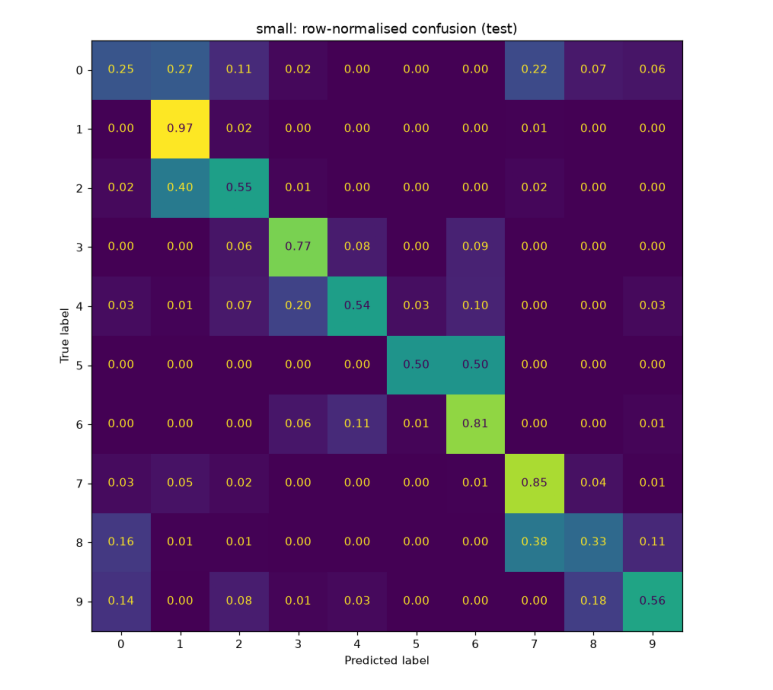

In [4]:
from matplotlib.image import imread
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(imread("../reports/small_confusion.png"))
ax.axis("off")
plt.tight_layout()

The diagonal is strong on the big, visually distinct classes (round smooth galaxies, edge-on disks), which is where the model is confident. The errors sit where you would expect: the three smooth classes bleed into each other (completely-round vs in-between-round is a genuinely fuzzy boundary), and the rarest classes have too few examples to learn. That is roughly the limit of a small from-scratch net. In the next notebook I check whether a pre-trained backbone does better.

**In the real project:** `src/galaxy_cnn/model.py` (`SmallCNN`), `src/galaxy_cnn/train.py` (the weighted-loss, macro-F1-selected training loop), `src/galaxy_cnn/evaluate.py` (the report and confusion matrix).

**Try it yourself:** drop the class weights (`CrossEntropyLoss()` with no `weight=`) and retrain. Accuracy barely moves but macro-F1 drops, because the model stops trying on the rare classes.